# Grad-CAM en ResNet50 a lo largo de sus stages

Este notebook carga tu checkpoint de ResNet50 y muestra Grad-CAM lado a lado para `layer1`, `layer2`, `layer3` y `layer4`.

Pipeline:
1. Cargar modelo + checkpoint.
2. Ejecutar inferencia de una imagen.
3. Generar mapas Grad-CAM por stage.
4. Visualizar overlays comparativos.

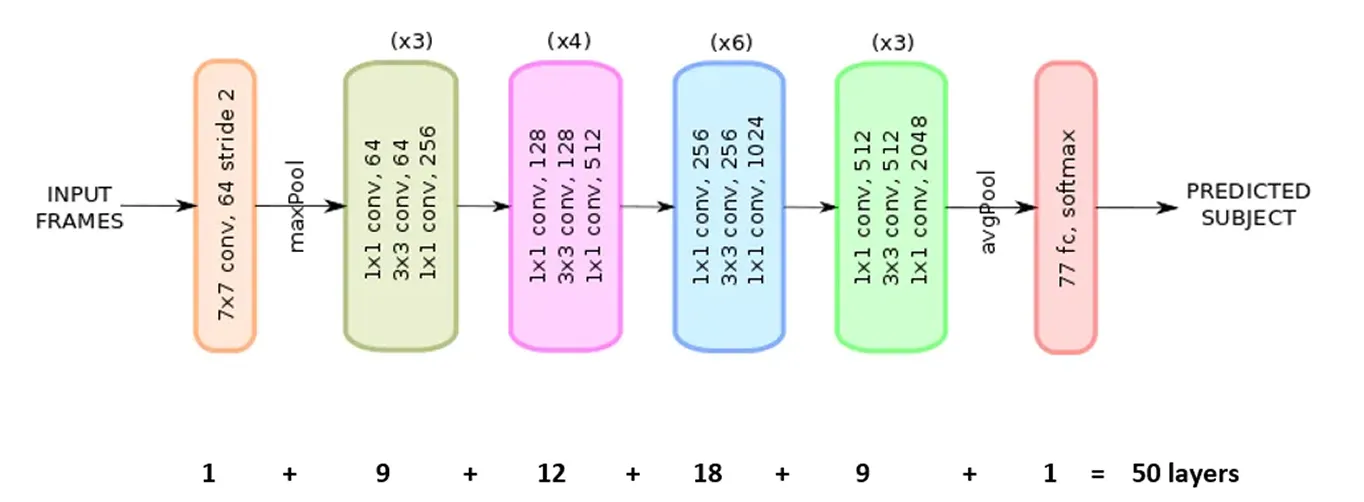

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet50

print('Torch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.11.0+cpu
CUDA disponible: False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuracion
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 9
class_labels = ['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

# Ajusta si mueves el notebook o el checkpoint
CKPT_PATH = Path('/content/drive/MyDrive/resnet50_finetune_layer4_layer3tail.pth')
IMAGE_PATH = '/content/drive/MyDrive/Imagenes_prueba/53.jpg'

if not CKPT_PATH.exists():
    raise FileNotFoundError(f'No se encontro checkpoint: {CKPT_PATH.resolve()}')

print('Dispositivo:', device)
print('Checkpoint:', CKPT_PATH.resolve())
print('Imagen:', IMAGE_PATH)

Dispositivo: cpu
Checkpoint: /content/drive/MyDrive/resnet50_finetune_layer4_layer3tail.pth
Imagen: /content/drive/MyDrive/Imagenes_prueba/53.jpg


In [ ]:
def crear_modelo_resnet50(num_classes, device):
    model = resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = torch.nn.Sequential(
        torch.nn.Dropout(p=0.30),
        torch.nn.Linear(in_features, num_classes),
    )
    return model.to(device)


def cargar_modelo(model, checkpoint_path, device):
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def validar_imagen(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'No existe la imagen: {path.resolve()}')
    if path.suffix.lower() not in VALID_EXTENSIONS:
        raise ValueError(f'Formato no soportado: {path.suffix}')
    return path


def transform_imagen(tam=224):
    return transforms.Compose([
        transforms.Resize((tam, tam)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=tensor.device).view(3, 1, 1)
    img = tensor * std + mean
    return torch.clamp(img, 0, 1)

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        self.hooks.append(self.target_layer.register_forward_hook(self._forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(self._backward_hook))

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam[0, 0]

        cam_min, cam_max = cam.min(), cam.max()
        if (cam_max - cam_min) > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
        pred_idx = int(np.argmax(probs))

        return cam.detach().cpu().numpy(), probs, pred_idx

In [ ]:
def overlay_heatmap_on_image(img_rgb, cam_map, alpha=0.45, cmap='jet'):
    heatmap = plt.get_cmap(cmap)(cam_map)[..., :3]
    overlay = (1 - alpha) * img_rgb + alpha * heatmap
    return np.clip(overlay, 0.0, 1.0)


def mostrar_gradcam_stages(model, input_tensor, img_rgb, class_labels, class_idx=None):
    stage_layers = {
        'layer1': model.layer1[-1],
        'layer2': model.layer2[-1],
        'layer3': model.layer3[-1],
        'layer4': model.layer4[-1],
    }

    cams = {}
    probs = None
    pred_idx = None

    for stage_name, layer in stage_layers.items():
        gc = GradCAM(model, layer)
        cam_map, probs, pred_idx = gc.generate(input_tensor, class_idx=class_idx)
        gc.remove_hooks()
        cams[stage_name] = cam_map

    pred_label = class_labels[pred_idx]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\nPred: {pred_label}')
    axes[0].axis('off')

    for i, (stage_name, cam_map) in enumerate(cams.items(), start=1):
        overlay = overlay_heatmap_on_image(img_rgb, cam_map)
        axes[i].imshow(overlay)
        axes[i].set_title(stage_name)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    return probs, pred_idx, cams

In [ ]:
# Cargar modelo
model = crear_modelo_resnet50(num_classes=num_classes, device=device)
model = cargar_modelo(model, CKPT_PATH, device)
print('Modelo cargado correctamente')

Modelo cargado correctamente


In [ ]:
# Preparar imagen
image_path = validar_imagen(IMAGE_PATH)
pil_img = Image.open(image_path).convert('RGB')

tfm = transform_imagen(tam=224)
input_tensor = tfm(pil_img).unsqueeze(0).to(device)

img_rgb = denormalize_image(input_tensor[0]).permute(1, 2, 0).detach().cpu().numpy()

print('Imagen lista para inferencia:', image_path)

Imagen lista para inferencia: /content/drive/MyDrive/Imagenes_prueba/53.jpg


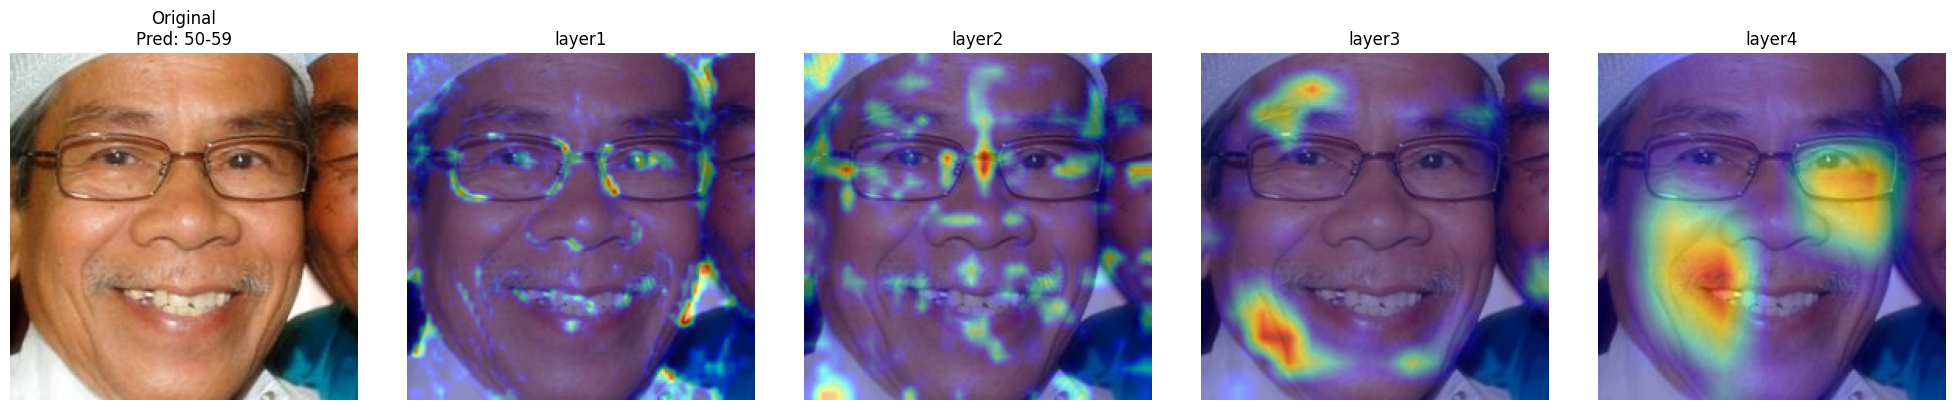

Clase predicha: 50-59
Top-5 probabilidades:
1. 50-59: 0.2556
2. 40-49: 0.2339
3. 30-39: 0.1648
4. 60-69: 0.1326
5. 20-29: 0.1190


In [ ]:

# Grad-CAM a lo largo de los stages
probs, pred_idx, cams = mostrar_gradcam_stages(model, input_tensor, img_rgb, class_labels)

print('Clase predicha:', class_labels[pred_idx])
print('Top-5 probabilidades:')
top5_idx = np.argsort(probs)[::-1][:5]
for rank, idx in enumerate(top5_idx, start=1):
    print(f'{rank}. {class_labels[idx]}: {probs[idx]:.4f}')

## Notas de interpretacion

- `layer1`: patrones locales y bordes basicos.
- `layer2`: partes mas estructuradas.
- `layer3`: regiones semanticas relevantes.
- `layer4`: evidencia mas discriminativa para la clase final.

Si quieres comparar otra clase (no la predicha), puedes pasar `class_idx` manualmente en la llamada a `mostrar_gradcam_stages`.

## Explicación del Notebook

## Explicación del Notebook

Este notebook está diseñado para demostrar y visualizar la técnica Grad-CAM (Gradient-weighted Class Activation Mapping) aplicada a un modelo ResNet50, enfocándose específicamente en sus diferentes etapas (capas). El objetivo principal es comprender en qué partes de una imagen de entrada se enfoca el modelo al tomar una decisión de clasificación, visualizando los mapas de activación de `layer1`, `layer2`, `layer3` y `layer4`.

### Resumen del proceso:
1.  **Cargar modelo + checkpoint**: Se carga un modelo ResNet50 pre-entrenado junto con un checkpoint personalizado que ha sido ajustado para una tarea específica.
2.  **Inferencia de imagen**: Se prepara una imagen de prueba y se pasa a través del modelo cargado para obtener una predicción.
3.  **Generar mapas Grad-CAM**: Para cada etapa ResNet especificada, se genera un mapa Grad-CAM. Este mapa resalta las regiones de la imagen que son importantes para la predicción del modelo.
4.  **Visualizar superposiciones**: Los mapas Grad-CAM generados se superponen a la imagen original, permitiendo una comparación lado a lado de lo que cada etapa enfoca.

Desglosemos cada sección del notebook:


### 1. Configuración e importación de librerías (Celdas: `8a636995`)

Esta celda importa todas las librerías Python necesarias para operaciones numéricas (`numpy`), trazado de gráficos (`matplotlib`), manipulación de imágenes (`PIL`) y funcionalidades de PyTorch para aprendizaje profundo (`torch`, `torchvision`). También imprime la versión de PyTorch y verifica la disponibilidad de CUDA, indicando si se puede usar una GPU para cálculos más rápidos.

### 2. Montaje de Google Drive (Celdas: `ooknvQ3agqJB`)

Esta celda monta tu Google Drive en el entorno de Colab. Esto es crucial para acceder a archivos como los checkpoints del modelo (`.pth`) y las imágenes de prueba almacenadas en tu Drive.

### 3. Configuración y ajuste de rutas (Celdas: `77f35257`)

Esta sección define los parámetros clave de configuración:
-   `device`: Establece automáticamente el dispositivo de cálculo a `cuda` (GPU) si está disponible, de lo contrario, a `cpu`.
-   `num_classes`: El número de clases de salida para la tarea de clasificación (por ejemplo, 9 grupos de edad).
-   `class_labels`: Una lista de etiquetas legibles para humanos que corresponden a `num_classes`.
-   `VALID_EXTENSIONS`: Un conjunto de extensiones de archivo de imagen soportadas.
-   `CKPT_PATH`: La ruta al archivo del checkpoint del modelo pre-entrenado en tu Google Drive.
-   `IMAGE_PATH`: La ruta al archivo de la imagen de prueba para la cual se generará Grad-CAM.

También incluye una comprobación para asegurar que el archivo del checkpoint existe e imprime el dispositivo elegido y las rutas de los archivos.

### 4. Funciones de ayuda (Celdas: `729fd599`)

Este bloque define varias funciones de utilidad:
-   **`crear_modelo_resnet50(num_classes, device)`**: Inicializa un modelo ResNet50. Carga un ResNet50 pre-entrenado (sin pesos pre-entrenados para la cabeza de clasificación) y reemplaza la capa completamente conectada final (`model.fc`) para que coincida con `num_classes` de tu tarea específica, añadiendo una capa de dropout para la regularización. Luego, el modelo se mueve al `device` especificado.
-   **`cargar_modelo(model, checkpoint_path, device)`**: Carga los pesos entrenados de un archivo checkpoint (`.pth`) en el `model`. Asegura que el modelo esté en modo de evaluación (`model.eval()`) para la inferencia.
-   **`validar_imagen(path)`**: Comprueba si existe un archivo de imagen en la `path` dada y si su extensión es compatible.
-   **`transform_imagen(tam)`**: Define una serie de transformaciones de imagen. Estas incluyen redimensionar la imagen a `tam`x`tam` (por ejemplo, 224x224 para ResNet50), convertirla a un tensor de PyTorch y normalizar sus valores de píxel utilizando la media y la desviación estándar estándar de ImageNet. Estos pasos preparan la imagen para la entrada en la red neuronal.
-   **`denormalize_image(tensor)`**: Revierte el proceso de normalización, convirtiendo un tensor normalizado de nuevo a una imagen visible con valores de píxel en el rango [0, 1]. Esto es útil para visualizar la imagen original.

### 5. Clase GradCAM (Celdas: `afb2e659`)

Esta es la parte central de la implementación de Grad-CAM. La clase `GradCAM` se inicializa con el `model` y una `target_layer` (por ejemplo, `model.layer4[-1]`).

-   **`_register_hooks()`**: Adjunta hooks de forward y backward a la `target_layer`. El hook de forward captura el mapa de características (activaciones) de la capa, y el hook de backward captura los gradientes que fluyen de vuelta a esa capa.
-   **`_forward_hook()` / `_backward_hook()`**: Estos métodos se llaman automáticamente durante los pases de forward y backward, respectivamente, para almacenar las activaciones y los gradientes.
-   **`remove_hooks()`**: Limpia los hooks adjuntos para evitar fugas de memoria.
-   **`generate(input_tensor, class_idx)`**: Este es el método principal para generar el mapa Grad-CAM:
    1.  Realiza un pase de forward con `input_tensor` para obtener `logits`.
    2.  Si no se proporciona `class_idx`, utiliza la clase con la puntuación más alta predicha (la predicción principal del modelo).
    3.  Luego calcula los gradientes de la puntuación para el `class_idx` objetivo con respecto a la salida de la `target_layer`. Esto se hace a través de `score.backward(retain_graph=True)`.
    4.  Los gradientes se agrupan (promedian) para obtener `weights`, que representan la importancia de cada canal del mapa de características.
    5.  Estos `weights` se multiplican por las `activations` (mapas de características) y se suman a través de los canales para crear un CAM (Class Activation Map) inicial.
    6.  Se aplica una activación ReLU (`F.relu(cam)`) para mantener solo las contribuciones positivas.
    7.  Luego, el CAM se escala (`F.interpolate`) al tamaño de la imagen original y se normaliza a un rango de [0, 1].
    8.  También calcula las probabilidades de clase y el índice de clase predicho.

Devuelve el CAM generado, las probabilidades de clase y el índice de clase predicho.

### 6. Funciones de visualización (Celdas: `78c8aa39`)

Este bloque contiene funciones para visualizar los resultados de Grad-CAM:
-   **`overlay_heatmap_on_image(img_rgb, cam_map, alpha, cmap)`**: Superpone el `cam_map` (mapa de calor) sobre el `img_rgb` (imagen original). Utiliza un mapa de colores (`cmap`, por defecto 'jet') y un valor `alpha` para controlar la transparencia del mapa de calor, creando una imagen mezclada donde las regiones importantes se resaltan.
-   **`mostrar_gradcam_stages(model, input_tensor, img_rgb, class_labels, class_idx)`**: Este es el orquestador para mostrar Grad-CAM para múltiples etapas:
    1.  Define `stage_layers`, mapeando nombres descriptivos ('layer1', 'layer2', etc.) al último bloque de cada etapa ResNet correspondiente.
    2.  Itera a través de estas etapas, creando una instancia `GradCAM` para cada una, generando el CAM y almacenándolo.
    3.  Luego crea una única figura con múltiples subplots. El primer subplot muestra la imagen original con la etiqueta predicha. Los subplots subsiguientes muestran la superposición Grad-CAM para cada etapa.
    4.  `plt.tight_layout()` y `plt.show()` aseguran que los gráficos se muestren correctamente.

Devuelve las probabilidades, el índice predicho y un diccionario de CAMs para cada etapa.

### 7. Carga y preparación del modelo (Celdas: `176b3773`)

Esta celda ejecuta el proceso de carga del modelo:
-   Llama a `crear_modelo_resnet50` para inicializar la arquitectura ResNet50 con el número de clases y el dispositivo especificados.
-   Luego, `cargar_modelo` carga los pesos pre-entrenados del `CKPT_PATH` en el modelo inicializado.
-   Se imprime un mensaje de confirmación `Modelo cargado correctamente` al cargarse exitosamente.

### 8. Preparación de la imagen para inferencia (Celdas: `91a80fc6`)

Esta celda prepara la imagen de prueba para la entrada al modelo:
-   Primero valida la `IMAGE_PATH` usando `validar_imagen`.
-   La imagen se abre usando PIL (`Image.open`) y se convierte al formato RGB.
-   La función `transform_imagen` se aplica a la imagen PIL para redimensionarla, convertirla a tensor y normalizarla. `unsqueeze(0)` añade una dimensión de lote (convirtiéndola en `[1, C, H, W]`), y `.to(device)` la mueve al dispositivo apropiado.
-   La función `denormalize_image` se utiliza para obtener una versión RGB visualizable de la imagen de entrada (`img_rgb`), que se utilizará para superponer los mapas de calor.
-   Se imprime un mensaje de confirmación `Imagen lista para inferencia`.

### 9. Generación y visualización de Grad-CAM (Celdas: `d3bc7c82`)

Aquí es donde se realiza la visualización de Grad-CAM:
-   Llama a `mostrar_gradcam_stages` con el modelo cargado, el tensor de entrada preparado, la imagen RGB desnormalizada y las etiquetas de clase. Esta función genera y muestra las visualizaciones Grad-CAM lado a lado para cada etapa de ResNet.
-   Después de la visualización, imprime la etiqueta de clase predicha y las 5 principales probabilidades de clase, proporcionando un resumen claro de la predicción del modelo.

### 10. Notas de interpretación (Celdas: `33076d13`)

Esta celda Markdown proporciona orientación sobre cómo interpretar los resultados de Grad-CAM de diferentes capas:
-   **`layer1`**: Se espera que muestre un enfoque en características de bajo nivel como bordes y texturas.
-   **`layer2`**: Se enfoca en partes más estructuradas de los objetos.
-   **`layer3`**: Resalta regiones semánticamente relevantes, identificando partes del objeto.
-   **`layer4`**: Muestra la evidencia más discriminativa para la predicción de clase final, a menudo señalando las características más cruciales del objeto.

También señala que puedes especificar manualmente `class_idx` en `mostrar_gradcam_stages` para ver Grad-CAM para una clase diferente a la predicha.